# 06. Simple Trend Cash: Miyazaki / OUR 比較

このノートブックの目的は、複雑なEarlyゲートをいったん捨て、経済的に説明しやすい防御ルールだけで、米国債戦略をどこまで改善できるかを検証することである。

これまでの防御戦略では、金利上昇、BEI、実質金利、イールドカーブ反転、2年金利、複数の閾値、score制、cash下限、duration cap、penalty multiplierを組み合わせた。成績は良いが、なぜその数値なのかを説明する負担が大きい。

ここでは発想を絞る。

$$
\text{最近の金利上昇ペースが続くなら、デュレーションでどれだけ損をしそうか}
$$

だけを見る。

この想定損失を、Miyazaki型またはOUR型の相対価値シグナルから差し引き、調整後の債券シグナルと3か月金利Cashを同じ最適化問題で比較する。債券がCashに勝てなければ自然にCashへ寄る。

## 比較する戦略

| 戦略名 | 内容 |
|---|---|
| `CASH_3M` | 3か月金利Cash |
| `BM_equal` | 13セクター等加重債券 |
| `MZ_SIGNAL6_NO_CASH` | Miyazaki型 `MZ_ALPHA` を半年シグナルで計算し、月次比較用に `signal / 6`。Cashなしで債券13セクターに完全投資 |
| `MZ_SIGNAL6_CASH` | Miyazaki型 `MZ_ALPHA` を半年シグナルで計算し、月次比較用に `signal / 6`。Cashも投資対象に含める |
| `OUR_SIGNAL_CASH` | OUR月次残差平均回帰シグナル |
| `MZ_SIMPLE_TREND_CASH` | MZに名目金利トレンド損失を控除 |
| `MZ_TREND_CASH_ADVANCED_V2` | MZに政策・インフレ型の防御圧力と2s10逆イールドCashハードルを接続 |
| `OUR_SIMPLE_TREND_CASH` | OURに名目金利トレンド損失を控除 |
| `MZ_SIMPLE_TREND_BEI_CASH` | MZに名目金利トレンド + BEI Momentumを控除 |
| `OUR_SIMPLE_TREND_BEI_CASH` | OURに名目金利トレンド + BEI Momentumを控除 |

このノートブックだけで検証の意味が追えるように、データ、債券価格、実現リターン、因子モデル、シグナル、最適化、評価指標をすべて順に説明する。なお、`MZ_SIGNAL6_NO_CASH` はCash導入の効果を切り分けるための比較対象であり、セクター上限35%とDuration上限8年は既存比較と同じまま維持する。


## 1. セットアップ

このノートブックは、先に `00_data_acquisition_for_06.ipynb` を実行して作成した単一ファイル `data/us_treasury_macro_for_06.xlsx` だけを入力として使う。

この入力ファイルには、以下のシートが含まれる。

- `yields`: 1Yから30Yまでの13セクター合成米国債利回り
- `source_nodes`: 6か月、1年、2年、3年、5年、7年、10年、30年のFRED CMTノード
- `macro_monthly`: 3か月金利、2年金利、10年金利、30年金利、および任意列として10年BEI・10年TIPS実質金利
- `coverage`, `monthly_missing_check`, `metadata`: 取得範囲と欠損確認

バックテスト期間は固定日付で切らない。データ取得ノートブックが保存した月次データの共通範囲から自動的に決める。24か月のローリング因子モデルを使うため、最初のシグナル日は「入力データの25番目の月末」、最後のシグナル日は「翌月リターンが観測できる最後から2番目の月末」である。

BEIの優先度は低いため、`T10YIE` が存在しない1981年から2002年まではBEI Momentumを0として扱う。主役の `MZ_SIMPLE_TREND_CASH` はBEIを使わないので、この処理は主戦略のバックテスト期間を制限しない。

In [1]:
import sys
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
from scipy.interpolate import CubicSpline
from scipy.optimize import linprog
from sklearn.decomposition import FactorAnalysis
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import japanize_matplotlib  # noqa: F401

DATA_PATH = Path("../data/us_treasury_macro_for_06.xlsx")
RESULT_PATH = Path("../data/backtest_simple_trend_cash_comparison.xlsx")
DATA_SOURCE_NOTEBOOK = Path("00_data_acquisition_for_06.ipynb")

CURVE_NODES = np.array([0.5, 1, 2, 3, 5, 7, 10, 30], dtype=float)
MATURITIES = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20, 30], dtype=float)
SECTOR_NAMES = ["1Y", "2Y", "3Y", "4Y", "5Y", "6Y", "7Y", "8Y", "9Y", "10Y", "15Y", "20Y", "30Y"]
N_SECTORS = len(MATURITIES)

LOOKBACK_MONTHS = 24
MIN_BACKTEST_SIGNAL = None  # データから自動決定する

MIYAZAKI_SIGNAL_HORIZON = 0.5
MIYAZAKI_GAMMA = 0.5
MONTHLY_GAMMA = 1 - 0.5 ** (1 / 6)

MAX_WEIGHT = 0.35
MAX_PORTFOLIO_DURATION = 8.0
CASH_DURATION = 0.25
TRANSACTION_COST_BPS = 2.0
BEI_MOMENTUM_WEIGHT = 0.5

print(f"Miyazaki半年γ: {MIYAZAKI_GAMMA:.3f}")
print(f"OUR月次γ: {MONTHLY_GAMMA:.4f}")
print(f"BEI Momentum係数: {BEI_MOMENTUM_WEIGHT:.2f}")

Miyazaki半年γ: 0.500
OUR月次γ: 0.1091
BEI Momentum係数: 0.50


## 2. データ読み込み

債券セクターは、1Yから30Yまでの13セクターを使う。これは実際のETFやインデックスそのものではなく、FREDのCMT利回りから合成したパー債セクターである。

Cashは3か月金利 `DGS3MO` を使う。1か月リターンは、月末時点の3か月金利を年率から月次へ換算する簡易近似である。

この長期版では、バックテスト期間を伸ばすことを優先する。`T10YIE` と `DFII10` は2003年以降しか存在しないため、必須列ではなく任意列として扱う。BEI Momentumには10年BEI `T10YIE` を使うが、BEIが欠損している期間ではBEI上昇ペースを0とみなす。

ここでは、06の入力ファイルに含まれる `coverage` と `monthly_missing_check` も読み、利回り、補間元ノード、主戦略に必要なMacro列に欠損がないことを確認する。

In [2]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"{DATA_PATH} が見つかりません。先に notebook/{DATA_SOURCE_NOTEBOOK} を実行してください。"
    )

with pd.ExcelFile(DATA_PATH) as xl:
    yields = pd.read_excel(xl, sheet_name="yields", index_col=0, parse_dates=True)[SECTOR_NAMES]
    curve_nodes = pd.read_excel(xl, sheet_name="source_nodes", index_col=0, parse_dates=True)
    macro = pd.read_excel(xl, sheet_name="macro_monthly", index_col=0, parse_dates=True)
    input_metadata = pd.read_excel(xl, sheet_name="metadata")
    input_coverage = pd.read_excel(xl, sheet_name="coverage")
    input_monthly_missing_check = pd.read_excel(xl, sheet_name="monthly_missing_check", index_col=0, parse_dates=True)

mandatory_macro_cols = ["DGS3MO", "DGS2", "DGS10", "DGS30", "SLOPE_10Y_3M"]
optional_macro_cols = ["T10YIE", "DFII10", "REAL10_PROXY"]
required_macro_cols = mandatory_macro_cols + optional_macro_cols

missing_mandatory_cols = sorted(set(mandatory_macro_cols) - set(macro.columns))
if missing_mandatory_cols:
    raise ValueError(f"macro_monthly に必須列がありません: {missing_mandatory_cols}")

for col in optional_macro_cols:
    if col not in macro.columns:
        macro[col] = np.nan

macro = macro[required_macro_cols]

common_index = yields.index.intersection(curve_nodes.index).intersection(macro.index).sort_values()
if common_index.empty:
    raise RuntimeError("yields, source_nodes, macro_monthly の共通月末がありません。")

if len(common_index) != len(yields.index) or len(common_index) != len(curve_nodes.index) or len(common_index) != len(macro.index):
    print("注意: 入力シート間で月末範囲が完全一致していないため、共通月末に揃えます。")
    print(f"  yields      : {yields.index[0].date()}〜{yields.index[-1].date()}, n={len(yields)}")
    print(f"  source_nodes: {curve_nodes.index[0].date()}〜{curve_nodes.index[-1].date()}, n={len(curve_nodes)}")
    print(f"  macro       : {macro.index[0].date()}〜{macro.index[-1].date()}, n={len(macro)}")
    print(f"  common      : {common_index[0].date()}〜{common_index[-1].date()}, n={len(common_index)}")

yields = yields.loc[common_index]
curve_nodes = curve_nodes.loc[common_index]
macro = macro.loc[common_index]

missing_summary = pd.DataFrame({
    "sheet": ["yields", "source_nodes", "macro_mandatory", "macro_optional"],
    "start": [yields.index[0], curve_nodes.index[0], macro.index[0], macro.index[0]],
    "end": [yields.index[-1], curve_nodes.index[-1], macro.index[-1], macro.index[-1]],
    "rows": [len(yields), len(curve_nodes), len(macro), len(macro)],
    "missing_cells": [
        int(yields.isna().sum().sum()),
        int(curve_nodes.isna().sum().sum()),
        int(macro[mandatory_macro_cols].isna().sum().sum()),
        int(macro[optional_macro_cols].isna().sum().sum()),
    ],
})

display(missing_summary)
display(input_metadata)

if missing_summary.loc[missing_summary["sheet"] != "macro_optional", "missing_cells"].sum() != 0:
    raise RuntimeError("主戦略に必要な入力データに欠損があります。データ取得ノートブックの結果を確認してください。")

if len(yields) <= LOOKBACK_MONTHS + 1:
    raise RuntimeError("24か月の履歴と翌月リターンを確保するにはデータ月数が不足しています。")

BACKTEST_START = yields.index[LOOKBACK_MONTHS]
if MIN_BACKTEST_SIGNAL is not None:
    BACKTEST_START = max(MIN_BACKTEST_SIGNAL, BACKTEST_START)
BACKTEST_LAST_SIGNAL = yields.index[-2]
BACKTEST_END_RETURN = yields.index[-1]

if BACKTEST_LAST_SIGNAL < BACKTEST_START:
    raise RuntimeError("バックテスト可能期間がありません。")

print(f"入力データ: {DATA_PATH}")
print(f"利回りデータ: {yields.index[0].date()}〜{yields.index[-1].date()}, shape={yields.shape}")
print(f"補間元ノード: {curve_nodes.columns.tolist()}")
print(f"マクロデータ: {macro.index[0].date()}〜{macro.index[-1].date()}, shape={macro.shape}")
print(f"BEI最初の有効月: {macro['T10YIE'].first_valid_index().date() if macro['T10YIE'].first_valid_index() is not None else 'なし'}")
print(f"バックテストシグナル期間: {BACKTEST_START.date()}〜{BACKTEST_LAST_SIGNAL.date()}")
print(f"バックテストリターン期間: {yields.index[yields.index.get_loc(BACKTEST_START) + 1].date()}〜{BACKTEST_END_RETURN.date()}")

print("\nmacro_monthly先頭:")
display(macro[["DGS3MO", "DGS2", "DGS10", "T10YIE", "DFII10", "SLOPE_10Y_3M"]].head())

print("\nmacro_monthly末尾:")
display(macro[["DGS3MO", "DGS2", "DGS10", "T10YIE", "DFII10", "SLOPE_10Y_3M"]].tail())

print("\nmonthly_missing_check末尾:")
display(input_monthly_missing_check.tail())

,sheet,start,end,rows,missing_cells
0,yields,1981-09-30,2026-06-30,538,0
1,source_nodes,1981-09-30,2026-06-30,538,0
2,macro_mandatory,1981-09-30,2026-06-30,538,0
3,macro_optional,1981-09-30,2026-06-30,538,768


,key,value
0,run_date,2026-07-12
1,target_month_end,2026-06-30
2,first_complete_month_end,1981-09-30
3,last_complete_month_end,2026-06-30
4,lookback_months,24
5,first_signal_date,1983-09-30
6,first_return_date,1983-10-31
7,last_signal_date,2026-05-31
8,last_return_date,2026-06-30


入力データ: ../data/us_treasury_macro_for_06.xlsx
利回りデータ: 1981-09-30〜2026-06-30, shape=(538, 13)
補間元ノード: ['0.5Y', '1Y', '2Y', '3Y', '5Y', '7Y', '10Y', '30Y']
マクロデータ: 1981-09-30〜2026-06-30, shape=(538, 8)
BEI最初の有効月: 2003-01-31
バックテストシグナル期間: 1983-09-30〜2026-05-31
バックテストリターン期間: 1983-10-31〜2026-06-30

macro_monthly先頭:


,DGS3MO,DGS2,DGS10,T10YIE,DFII10,SLOPE_10Y_3M
1981-09-30,15.05,16.69,15.84,NaN,NaN,0.79
1981-10-31,13.33,14.59,14.63,NaN,NaN,1.30
1981-11-30,10.78,12.36,13.13,NaN,NaN,2.35
1981-12-31,11.54,13.63,13.98,NaN,NaN,2.44
1982-01-31,13.08,14.24,14.14,NaN,NaN,1.06



macro_monthly末尾:


,DGS3MO,DGS2,DGS10,T10YIE,DFII10,SLOPE_10Y_3M
2026-02-28,3.67,3.38,3.97,2.25,1.72,0.30
2026-03-31,3.70,3.79,4.30,2.30,2.00,0.60
2026-04-30,3.68,3.88,4.40,2.46,1.94,0.72
2026-05-31,3.69,3.98,4.45,2.38,2.07,0.76
2026-06-30,3.87,4.14,4.44,2.24,2.20,0.57



monthly_missing_check末尾:


,mandatory_missing_count,optional_missing_count,all_mandatory_complete
2026-02-28,0,0,True
2026-03-31,0,0,True
2026-04-30,0,0,True
2026-05-31,0,0,True
2026-06-30,0,0,True


## 3. 債券価格と月次実現リターン

各セクターは、時点 $t$ の利回りをクーポンとするパー債として扱う。

時点 $t$ で残存 $T_i$ 年のパー債を買い、次の月末 $t+1$ まで $\Delta_t$ 年だけ保有する。すると残存年限は $T_i-\Delta_t$ になる。

初期価格を $P_t$、翌月末評価価格を $P_{t+1}$ とすると、月次実現リターンは

$$
r_{i,t+1}
=
\frac{P_{t+1}}{P_t}-1
$$

である。

翌月末の評価利回りは、元CMTノードをスプライン補間して $T_i-\Delta_t$ 年点を読む。1Y債を1か月保有した後は1年未満になるため、元ノードには0.5Yも含める。

In [3]:
def year_fraction(start, end):
    return (end - start).days / 365.25


def cashflow_times(original_maturity, elapsed=0.0, freq=2):
    payment_times = np.arange(1 / freq, original_maturity + 1e-9, 1 / freq) - elapsed
    return payment_times[payment_times > 1e-10]


def price_bond_elapsed(y_coupon, y_discount, original_maturity, elapsed=0.0, freq=2):
    times = cashflow_times(original_maturity, elapsed=elapsed, freq=freq)
    if len(times) == 0:
        return 100.0
    coupon = y_coupon * 100 / freq
    cashflows = np.full(len(times), coupon)
    cashflows[-1] += 100
    return float(np.sum(cashflows / (1 + y_discount / freq) ** (freq * times)))


def dP_dy(y_coupon, y_discount, maturity, freq=2, dy=1e-5):
    p_up = price_bond_elapsed(y_coupon, y_discount + dy, maturity, elapsed=0.0, freq=freq)
    p_down = price_bond_elapsed(y_coupon, y_discount - dy, maturity, elapsed=0.0, freq=freq)
    return (p_up - p_down) / (2 * dy)


def d2P_dy2(y_coupon, y_discount, maturity, freq=2, dy=1e-4):
    p_up = price_bond_elapsed(y_coupon, y_discount + dy, maturity, elapsed=0.0, freq=freq)
    p0 = price_bond_elapsed(y_coupon, y_discount, maturity, elapsed=0.0, freq=freq)
    p_down = price_bond_elapsed(y_coupon, y_discount - dy, maturity, elapsed=0.0, freq=freq)
    return (p_up - 2 * p0 + p_down) / dy**2


def modified_duration(y, maturity, freq=2, dy=1e-4):
    p0 = price_bond_elapsed(y, y, maturity, elapsed=0.0, freq=freq)
    p_up = price_bond_elapsed(y, y + dy, maturity, elapsed=0.0, freq=freq)
    p_down = price_bond_elapsed(y, y - dy, maturity, elapsed=0.0, freq=freq)
    return -(p_up - p_down) / (2 * dy) / p0


def realized_sector_returns(row_sector_pct, next_node_pct, horizon):
    y_current = row_sector_pct.astype(float) / 100
    next_curve = CubicSpline(CURVE_NODES, next_node_pct.astype(float) / 100, extrapolate=True)
    returns = []
    for k, maturity in enumerate(MATURITIES):
        y_i = y_current[k]
        y_next = float(next_curve(maturity - horizon))
        p0 = price_bond_elapsed(y_i, y_i, maturity, elapsed=0.0)
        p1 = price_bond_elapsed(y_i, y_next, maturity, elapsed=horizon)
        returns.append(p1 / p0 - 1)
    return np.array(returns)


def cash_return(dt, horizon):
    return macro.loc[dt, "DGS3MO"] / 100 * horizon


for maturity in [1, 5, 10, 30]:
    print(f"{maturity:>2}Y par price @ 3%: {price_bond_elapsed(0.03, 0.03, maturity):.6f}")

 1Y par price @ 3%: 100.000000
 5Y par price @ 3%: 100.000000
10Y par price @ 3%: 100.000000
30Y par price @ 3%: 100.000000


## 4. ローリング3因子モデル

Miyazaki型とOUR型は、どちらも利回りカーブの3因子モデルを使う。

各月 $t$ で、過去24か月の13セクター利回りを標準化し、3因子モデルを推定する。そのモデルから、時点 $t$ のモデル利回り $\hat{y}_{i,t}$ と残差 $\varepsilon_{i,t}$ を得る。

$$
y_{i,t}
=
\hat{y}_{i,t}+\varepsilon_{i,t}
$$

残差が正なら、そのセクターの実際利回りはモデル利回りより高く、相対的に割安と見る。残差が負なら、モデルより利回りが低く、相対的に割高と見る。

重要なのは、因子モデルを全期間で一度に推定しないことである。各月の推定には、その月より前の24か月だけを使う。

In [4]:
def fit_factor_model(history_pct):
    scaler = StandardScaler()
    scaled = scaler.fit_transform(history_pct.values.astype(float))
    fa = FactorAnalysis(n_components=3, random_state=42, max_iter=2000)
    fa.fit(scaled)
    return scaler, fa.components_.T


def estimate_model_yield(y_pct, scaler, loadings):
    y_scaled = scaler.transform(y_pct.reshape(1, -1)).ravel()
    factor_values = np.linalg.lstsq(loadings, y_scaled, rcond=None)[0]
    model_scaled = loadings @ factor_values
    model_pct = model_scaled * scaler.scale_ + scaler.mean_
    residual_pct = y_pct - model_pct
    return model_pct, residual_pct, factor_values

## 5. MZ_SIGNAL6: 宮崎論文型シグナルを月次比較用に6で割る

`MZ_SIGNAL6` は、宮崎論文の提案手法に近い `CA&RD + 誤差項補正` を使う。

まず、半年後のロールダウン先を $T_i-0.5$ とする。モデルカーブからロールダウン先のモデル利回りを読み、現在のモデル利回りに残差修正を加えた利回りと比較する。

$$
\Delta y^{MZ}_{i,t}
=
\hat{y}_{t}(T_i-0.5)
-
\left(\hat{y}_{i,t}+0.5\varepsilon_{i,t}\right)
$$

ここで $0.5\varepsilon_{i,t}$ は、半年で残差の半分が修正されるという宮崎論文型の仮定である。

次に、キャリー、デュレーション、コンベクシティを使って半年リターン近似を計算する。

$$
S^{MZ,H}_{i,t}
=
\frac{
Carry_i
+
\frac{\partial P_i}{\partial y}\Delta y^{MZ}_{i,t}
+
\frac{1}{2}\frac{\partial^2 P_i}{\partial y^2}(\Delta y^{MZ}_{i,t})^2
}{P_i}
$$

ただし、このノートブックの実現リターンとCashは月次である。そこで、半年シグナルを月次比較用に単純に6で割る。

$$
S^{MZ}_{i,t}
=
\frac{S^{MZ,H}_{i,t}}{6}
$$

これは完全な月次版Miyazakiではない。今回の比較では、ユーザー指定どおり「宮崎論文の手法の月次化 = signal/6」を使う。

In [5]:
def miyazaki_card_taylor(y_i, delta_y, maturity, signal_horizon=MIYAZAKI_SIGNAL_HORIZON):
    p0 = price_bond_elapsed(y_i, y_i, maturity, elapsed=0.0)
    rolled_maturity = max(maturity - signal_horizon, 0.5)
    carry = y_i * 100 * signal_horizon
    duration_term = dP_dy(y_i, y_i, rolled_maturity) * delta_y
    convexity_term = 0.5 * d2P_dy2(y_i, y_i, rolled_maturity) * delta_y**2
    return (carry + duration_term + convexity_term) / p0


def mz_signal6(row_sector_pct, model_pct, residual_pct):
    y_current = row_sector_pct.astype(float) / 100
    model_curve = CubicSpline(MATURITIES, model_pct.astype(float) / 100, extrapolate=True)
    signals = []
    for k, maturity in enumerate(MATURITIES):
        y_i = y_current[k]
        rolled_maturity = max(maturity - MIYAZAKI_SIGNAL_HORIZON, 0.5)
        model_i = model_pct[k] / 100
        eps_i = residual_pct[k] / 100
        delta_alpha = float(model_curve(rolled_maturity)) - (model_i + MIYAZAKI_GAMMA * eps_i)
        half_year_signal = miyazaki_card_taylor(y_i, delta_alpha, maturity, MIYAZAKI_SIGNAL_HORIZON)
        signals.append(half_year_signal / 6)
    return np.array(signals)

## 6. OUR_SIGNAL: 月次残差平均回帰シグナル

`OUR_SIGNAL` は、最初から月次ホライズンで残差平均回帰を考える。

残差の半減期を6か月とすると、1か月あたりの修正率は

$$
\gamma_m
=
1-0.5^{1/6}
\approx 0.1091
$$

である。

時点 $t$ のセクター $i$ について、1か月後の予想利回りを

$$
y^{OUR}_{i,t+1}
=
y_{i,t}
+
\left(
\hat{y}_t(T_i-\Delta_t)
-
\hat{y}_{i,t}
-
\gamma_m\varepsilon_{i,t}
\right)
$$

と置く。

これを使って、時点 $t$ のパー債を1か月後の予想利回りで評価し、月次期待リターンを直接計算する。

In [6]:
def our_monthly_reversion_signal(row_sector_pct, model_pct, residual_pct, horizon):
    y_current = row_sector_pct.astype(float) / 100
    model_curve = CubicSpline(MATURITIES, model_pct.astype(float) / 100, extrapolate=True)
    signals = []
    for k, maturity in enumerate(MATURITIES):
        y_i = y_current[k]
        y_horizon = y_i + (
            float(model_curve(maturity - horizon))
            - model_pct[k] / 100
            - MONTHLY_GAMMA * residual_pct[k] / 100
        )
        p0 = price_bond_elapsed(y_i, y_i, maturity, elapsed=0.0)
        p1 = price_bond_elapsed(y_i, y_horizon, maturity, elapsed=horizon)
        signals.append(p1 / p0 - 1)
    return np.array(signals)

## 7. SIMPLE_TREND_CASH: 単一の経済的ペナルティ

このノートブックの防御ルールは、複雑なゲートではない。

考えるのは次の1点だけである。

> 直近3か月の金利上昇ペースが次の1か月も続いたら、デュレーションでどれだけ損をしそうか。

2年金利と10年金利の3か月変化を使い、1か月あたりの名目金利上昇ペースを

$$
m^{nom}_t
=
\max\left(
0,
\frac{\Delta_{3m}y^{2Y}_t}{3},
\frac{\Delta_{3m}y^{10Y}_t}{3}
\right)
$$

と定義する。

債券セクター $i$ の修正デュレーションを $D_{i,t}$ とすれば、想定レベル損失は概ね

$$
D_{i,t}m^{nom}_t
$$

である。したがって、調整後シグナルは

$$
\tilde{s}_{i,t}
=
s_{i,t}-D_{i,t}m^{nom}_t
$$

となる。

これは閾値ではない。ペナルティは金利上昇ペースに比例して連続的に大きくなる。

## 8. BEI Momentum: 閾値なしのプラスアルファ

BEI版では、10年BEIの3か月上昇ペースを弱く加える。

$$
m^{bei}_t
=
m^{nom}_t
+
0.5\max\left(0,\frac{\Delta_{3m}BEI^{10Y}_t}{3}\right)
$$

係数 $0.5$ は、BEI上昇が名目金利にすでに一部反映されているため、二重カウントを避けるための固定値である。

ここでも、BEI水準が何%以上なら危険という閾値は置かない。BEIが上がっていれば、インフレ期待上昇による名目債リスクを少し厚めに見るだけである。

## 8.5 MZ_TREND_CASH_ADVANCED_V2: policy inflation defense

以前のsigned版は、金利上昇ならDurationを減点し、金利低下ならDurationを加点する pressure だった。発想は自然だが、金利上昇局面と債券ラリー局面を1本の符号付きモメンタムで扱ったため、2011-2017年のような低インフレ・低金利環境を十分に取りに行けず、2022年の防御も `SIMPLE_TREND_CASH` ほど強くなかった。

そこでV2では、ラリーを無理に予測しない。防御すべき局面だけを、経済的に明確な2条件で定義する。

1. 政策・インフレ型の引き締め局面
2. 2年金利が10年金利を上回る逆イールド局面

3か月変化を月次ペースに直した値を使い、政策・インフレ型の引き締めフラグを

$$
I^{PI}_t
=
\mathbf{1}\left\{
\frac{\Delta_{3m}y^{2Y}_t}{3}>0,
\frac{\Delta_{3m}y^{3M}_t}{3}>0,
\frac{\Delta_{3m}BEI^{10Y}_t}{3}>0
\right\}
$$

と定義する。2年金利は政策金利期待、3か月金利は実際のCash利回り、BEIはインフレ期待を表す。3つが同時に上がっているときは、債券にとって単なるノイズではなく、金融引き締めとインフレ期待上昇が同時に起きている局面と考える。

逆イールドフラグは、

$$
I^{INV}_t
=
\mathbf{1}\left\{y^{2Y}_t>y^{10Y}_t\right\}
$$

である。これは、長期債を持つためにはCash・短期金利対比で明確な追加リターンが必要な局面を表す。

防御フラグを

$$
I_t=I^{PI}_t \lor I^{INV}_t
$$

とし、防御圧力を

$$
m^{v2}_t
=
I_t
\left[
\max\left(0,
\frac{\Delta_{3m}y^{2Y}_t}{3},
\frac{\Delta_{3m}y^{10Y}_t}{3}
\right)
+0.5\max\left(0,\frac{\Delta_{3m}BEI^{10Y}_t}{3}\right)
\right]
$$

と置く。

さらに、2s10逆イールド時には、Cash優位を明示的にシグナルから控除する。

$$
h^{v2}_t
=
\max\left(0,\frac{y^{2Y}_t-y^{10Y}_t}{12}\right)
$$

したがって、債券セクター $i$ の調整後シグナルは、

$$
\tilde{s}_{i,t}
=
s_{i,t}-D_{i,t}m^{v2}_t-h^{v2}_t
$$

である。

このルールの狙いは、2011-2017年のような低インフレ・低金利局面では過剰にCashへ逃げず、2022年のような政策金利・Cash利回り・インフレ期待が同時に上がる局面では強くDurationを抑制することにある。閾値水準は使わず、使うのは符号、逆イールド、観測された金利変化だけである。


In [7]:
def trailing_change(dt, column, months):
    current = macro.loc[dt, column]
    if pd.isna(current):
        return 0.0
    hist = macro.loc[:dt, column].dropna()
    if len(hist) < months + 1:
        return 0.0
    if hist.index[-1] != dt:
        return 0.0
    return current - hist.iloc[-months - 1]


def monthly_change_rate(dt, column, months=3):
    return trailing_change(dt, column, months) / 100 / months


def nominal_trend_move(dt):
    d2_3m = max(0.0, monthly_change_rate(dt, "DGS2"))
    d10_3m = max(0.0, monthly_change_rate(dt, "DGS10"))
    return max(0.0, d2_3m, d10_3m)


def bei_trend_move(dt):
    bei_3m = max(0.0, monthly_change_rate(dt, "T10YIE"))
    return nominal_trend_move(dt) + BEI_MOMENTUM_WEIGHT * bei_3m


def advanced_v2_policy_inflation_flag(dt):
    # BEIがない期間は、政策・インフレ同時上昇flagを立てない。
    return (
        monthly_change_rate(dt, "DGS2") > 0
        and monthly_change_rate(dt, "DGS3MO") > 0
        and monthly_change_rate(dt, "T10YIE") > 0
    )


def advanced_v2_inversion_flag(dt):
    return macro.loc[dt, "DGS2"] > macro.loc[dt, "DGS10"]


def advanced_v2_defense_flag(dt):
    return advanced_v2_policy_inflation_flag(dt) or advanced_v2_inversion_flag(dt)


def advanced_v2_pressure(dt):
    if not advanced_v2_defense_flag(dt):
        return 0.0
    d2_3m = max(0.0, monthly_change_rate(dt, "DGS2"))
    d10_3m = max(0.0, monthly_change_rate(dt, "DGS10"))
    bei_3m = max(0.0, monthly_change_rate(dt, "T10YIE"))
    return max(0.0, d2_3m, d10_3m) + BEI_MOMENTUM_WEIGHT * bei_3m


def advanced_v2_cash_hurdle(dt):
    return max(0.0, (macro.loc[dt, "DGS2"] - macro.loc[dt, "DGS10"]) / 100 / 12)


def apply_trend_penalty(signal, durations, dt, mode):
    if mode == "none":
        move = 0.0
        hurdle = 0.0
    elif mode == "nominal":
        move = nominal_trend_move(dt)
        hurdle = 0.0
    elif mode == "bei":
        move = bei_trend_move(dt)
        hurdle = 0.0
    elif mode == "advanced_v2":
        move = advanced_v2_pressure(dt)
        hurdle = advanced_v2_cash_hurdle(dt)
    else:
        raise ValueError(f"unknown trend mode: {mode}")
    return signal - durations * move - hurdle, move, hurdle


## 9. Cash込み最適化とCashなし最適化

`MZ_SIGNAL6_NO_CASH` 以外では、債券13セクターとCashを同じ投資候補にする。目的関数は、債券の調整後シグナルとCashリターンの期待値を最大化する。

`MZ_SIGNAL6_NO_CASH` は比較用に、Cashを投資候補から外し、債券13セクターだけで完全投資する。これにより、宮崎型シグナルそのものと、Cash退避を入れた改変版の差を確認できる。

制約は共通である。

- ロングオンリー
- 完全投資
- 債券1セクター上限35%
- Cash 0%から100%。ただし `MZ_SIGNAL6_NO_CASH` はCashを0%に固定
- ポートフォリオDuration上限8年

今回は、Cash下限、score制、crisis/caution/risk_on状態、penalty multiplierは使わない。

Cash込み戦略でCashへ行く理由は非常に単純である。

$$
\text{調整後の債券シグナルがCashより悪いからCashを持つ}
$$

だけである。

In [8]:
def optimize_with_cash_simple(signal_bonds, durations, cash_ret):
    signals = np.r_[signal_bonds, cash_ret]
    asset_durations = np.r_[durations, CASH_DURATION]

    a_ub = np.array([asset_durations])
    b_ub = np.array([MAX_PORTFOLIO_DURATION])
    a_eq = np.ones((1, N_SECTORS + 1))
    b_eq = np.array([1.0])
    bounds = [(0.0, MAX_WEIGHT)] * N_SECTORS + [(0.0, 1.0)]

    res = linprog(
        -signals,
        A_ub=a_ub,
        b_ub=b_ub,
        A_eq=a_eq,
        b_eq=b_eq,
        bounds=bounds,
        method="highs",
    )
    if not res.success:
        raise RuntimeError(res.message)
    return res.x


def optimize_bond_only_simple(signal_bonds, durations):
    a_ub = np.array([durations])
    b_ub = np.array([MAX_PORTFOLIO_DURATION])
    a_eq = np.ones((1, N_SECTORS))
    b_eq = np.array([1.0])
    bounds = [(0.0, MAX_WEIGHT)] * N_SECTORS

    res = linprog(
        -signal_bonds,
        A_ub=a_ub,
        b_ub=b_ub,
        A_eq=a_eq,
        b_eq=b_eq,
        bounds=bounds,
        method="highs",
    )
    if not res.success:
        raise RuntimeError(res.message)
    return res.x


def one_way_turnover(new_weight, old_weight):
    return 0.5 * np.abs(new_weight - old_weight).sum()


def apply_transaction_cost(gross_return, turnover, tc_bps=TRANSACTION_COST_BPS):
    return gross_return - turnover * tc_bps / 10000

## 10. バックテスト実行

各月末 $t$ で行うことは以下である。

1. 過去24か月だけで3因子モデルを推定する。
2. 時点 $t$ のモデル利回りと残差を計算する。
3. `MZ_SIGNAL6` と `OUR_SIGNAL` を計算する。
4. 必要に応じて、名目金利トレンドまたはBEI Momentumのペナルティを差し引く。
5. `MZ_SIGNAL6_NO_CASH` 以外は、債券13セクターとCashを同じ最適化問題に入れる。
6. 翌月末 $t+1$ の実現リターンで評価する。

バックテスト期間は、入力データから自動決定する。今回の長期データ取得ノートブックでは、必須系列が1981年9月から2026年6月まで揃う。したがって、24か月履歴を確保した最初のシグナルは1983年9月末、最初のリターンは1983年10月末になる。

BEIは2003年以降だけ利用できる任意データである。BEI系戦略は、BEIが存在しない期間ではBEIペナルティを0として扱う。

In [9]:
strategy_config = {
    "MZ_SIGNAL6_NO_CASH": {"signal": "mz", "trend": "none", "cash": False},
    "MZ_SIGNAL6_CASH": {"signal": "mz", "trend": "none", "cash": True},
    "OUR_SIGNAL_CASH": {"signal": "our", "trend": "none", "cash": True},
    "MZ_SIMPLE_TREND_CASH": {"signal": "mz", "trend": "nominal", "cash": True},
    "MZ_TREND_CASH_ADVANCED_V2": {"signal": "mz", "trend": "advanced_v2", "cash": True},
    "OUR_SIMPLE_TREND_CASH": {"signal": "our", "trend": "nominal", "cash": True},
    "MZ_SIMPLE_TREND_BEI_CASH": {"signal": "mz", "trend": "bei", "cash": True},
    "OUR_SIMPLE_TREND_BEI_CASH": {"signal": "our", "trend": "bei", "cash": True},
}

return_cols = ["CASH_3M", "BM_equal"] + list(strategy_config.keys())
returns_gross = {col: [] for col in return_cols}
returns_net = {col: [] for col in return_cols}
weights = {name: [] for name in strategy_config}
turnovers = {name: [] for name in strategy_config}
trend_records = []
rebalance_dates = []

prev_weights = {name: np.r_[np.zeros(N_SECTORS), 1.0] for name in strategy_config}
all_dates = yields.index

for dt in all_dates[:-1]:
    if dt < BACKTEST_START or dt > BACKTEST_LAST_SIGNAL:
        continue

    loc = all_dates.get_loc(dt)
    history = yields.iloc[loc - LOOKBACK_MONTHS:loc]
    if len(history) < LOOKBACK_MONTHS:
        continue

    next_dt = all_dates[loc + 1]
    horizon = year_fraction(dt, next_dt)

    row_sector = yields.loc[dt].values.astype(float)
    next_nodes = curve_nodes.loc[next_dt].values.astype(float)

    scaler, loadings = fit_factor_model(history)
    model_pct, residual_pct, factor_values = estimate_model_yield(row_sector, scaler, loadings)

    durations = np.array([modified_duration(row_sector[k] / 100, maturity) for k, maturity in enumerate(MATURITIES)])
    realized = realized_sector_returns(row_sector, next_nodes, horizon)
    c_ret = cash_return(dt, horizon)

    mz_base = mz_signal6(row_sector, model_pct, residual_pct)
    our_base = our_monthly_reversion_signal(row_sector, model_pct, residual_pct, horizon)
    signal_lookup = {"mz": mz_base, "our": our_base}

    benchmark_weight = np.ones(N_SECTORS) / N_SECTORS
    bm_ret = benchmark_weight @ realized

    rebalance_dates.append(next_dt)
    returns_gross["CASH_3M"].append(c_ret)
    returns_net["CASH_3M"].append(c_ret)
    returns_gross["BM_equal"].append(bm_ret)
    returns_net["BM_equal"].append(bm_ret)

    trend_records.append({
        "signal_date": dt,
        "return_date": next_dt,
        "nominal_move_monthly": nominal_trend_move(dt),
        "bei_move_monthly": bei_trend_move(dt),
        "advanced_v2_pressure_monthly": advanced_v2_pressure(dt),
        "advanced_v2_cash_hurdle_monthly": advanced_v2_cash_hurdle(dt),
        "advanced_v2_defense_flag": advanced_v2_defense_flag(dt),
        "advanced_v2_policy_inflation_flag": advanced_v2_policy_inflation_flag(dt),
        "advanced_v2_inversion_flag": advanced_v2_inversion_flag(dt),
        "signed_DGS3MO_move_monthly": monthly_change_rate(dt, "DGS3MO"),
        "signed_DGS2_move_monthly": monthly_change_rate(dt, "DGS2"),
        "signed_DGS10_move_monthly": monthly_change_rate(dt, "DGS10"),
        "signed_BEI_move_monthly": monthly_change_rate(dt, "T10YIE"),
        "curve_2y10y_spread": macro.loc[dt, "DGS2"] - macro.loc[dt, "DGS10"],
        "DGS3MO_3m_change": trailing_change(dt, "DGS3MO", 3),
        "DGS2_3m_change": trailing_change(dt, "DGS2", 3),
        "DGS10_3m_change": trailing_change(dt, "DGS10", 3),
        "T10YIE_3m_change": trailing_change(dt, "T10YIE", 3),
    })

    for name, config in strategy_config.items():
        base_signal = signal_lookup[config["signal"]]
        adjusted_signal, move, hurdle = apply_trend_penalty(base_signal, durations, dt, config["trend"])
        asset_returns = np.r_[realized, c_ret]

        if config["cash"]:
            weight = optimize_with_cash_simple(adjusted_signal, durations, c_ret)
        else:
            bond_weight = optimize_bond_only_simple(adjusted_signal, durations)
            weight = np.r_[bond_weight, 0.0]

        gross_return = weight @ asset_returns
        turnover = one_way_turnover(weight, prev_weights[name])
        net_return = apply_transaction_cost(gross_return, turnover)

        weights[name].append(weight)
        turnovers[name].append(turnover)
        returns_gross[name].append(gross_return)
        returns_net[name].append(net_return)
        prev_weights[name] = weight

returns_gross = pd.DataFrame(returns_gross, index=rebalance_dates)
returns_net = pd.DataFrame(returns_net, index=rebalance_dates)
turnover_df = pd.DataFrame(turnovers, index=rebalance_dates)
trend_df = pd.DataFrame(trend_records)
weight_dfs = {
    name: pd.DataFrame(values, index=[d - pd.offsets.MonthEnd(1) for d in rebalance_dates], columns=SECTOR_NAMES + ["Cash"])
    for name, values in weights.items()
}

print(f"バックテスト月数: {len(returns_net)}")
print(f"リターン期間: {returns_net.index[0].date()}〜{returns_net.index[-1].date()}")
display(returns_net.tail())


バックテスト月数: 513
リターン期間: 1983-10-31〜2026-06-30


,CASH_3M,BM_equal,MZ_SIGNAL6_NO_CASH,MZ_SIGNAL6_CASH,OUR_SIGNAL_CASH,MZ_SIMPLE_TREND_CASH,MZ_TREND_CASH_ADVANCED_V2,OUR_SIMPLE_TREND_CASH,MZ_SIMPLE_TREND_BEI_CASH,OUR_SIMPLE_TREND_BEI_CASH
2026-02-28,0.002813,0.021886,0.025347,0.025333,0.023886,0.002664,0.025333,0.002662,0.002664,0.002662
2026-03-31,0.003115,-0.015820,-0.017650,-0.017365,-0.017681,-0.017405,-0.017365,-0.017813,-0.017405,-0.017813
2026-04-30,0.003039,-0.004775,-0.003653,-0.003624,-0.003560,0.002902,0.002902,0.002895,0.002902,0.002895
2026-05-31,0.003123,-0.000431,0.001372,0.001488,0.000658,0.003123,0.003123,0.003123,0.003123,0.003123
2026-06-30,0.003031,0.003605,0.006529,0.006529,0.006713,0.003031,0.003031,0.003031,0.003031,0.003031


## 11. 評価指標

評価はネットリターンを重視する。取引コストは、片道100%売買あたり2bpとする。

主な指標は以下である。

- 年率リターン: 月次リターンを幾何平均で年率化
- 年率ボラ: 月次標準偏差を $\sqrt{12}$ 倍
- 最大DD: 累積リターンのピークからの最大下落率
- 2022年リターン: 2022年の月次リターン単純合計
- 短期金利超過: Cash 3Mに対する年率平均超過
- IR vs Cash: 短期金利超過をCash対比TEで割った値
- 短期金利負け月率: 月次でCash 3Mに負けた割合
- 平均Cash比率、平均Duration

今回の目的は、債券ベンチマークに勝つことだけではない。短期金利と比べて、債券リスクを取る価値があるかを重視する。

In [10]:
def annualized_return(ret):
    ret = pd.Series(ret).dropna()
    return (1 + ret).prod() ** (12 / len(ret)) - 1


def annualized_vol(ret):
    return pd.Series(ret).dropna().std(ddof=1) * np.sqrt(12)


def max_drawdown(ret):
    wealth = (1 + pd.Series(ret).dropna()).cumprod()
    return (wealth / wealth.cummax() - 1).min()


def portfolio_duration_series(wdf):
    values = []
    for dt, weight_row in wdf.iterrows():
        row_sector = yields.loc[dt].values.astype(float)
        durations = np.array([modified_duration(row_sector[k] / 100, maturity) for k, maturity in enumerate(MATURITIES)])
        values.append(weight_row.values @ np.r_[durations, CASH_DURATION])
    return pd.Series(values, index=wdf.index)


def performance_table(returns, cash_col="CASH_3M"):
    rows = []
    cash = returns[cash_col]
    for col in returns.columns:
        r = returns[col].dropna()
        row = {
            "年率リターン(幾何)": annualized_return(r),
            "年率ボラ": annualized_vol(r),
            "最大DD": max_drawdown(r),
            "2022年リターン": r.loc["2022"].sum(),
        }
        if col != cash_col:
            excess = r - cash.reindex(r.index)
            te = excess.std(ddof=1) * np.sqrt(12)
            row.update({
                "短期金利超過": excess.mean() * 12,
                "TE_vs_cash": te,
                "IR_vs_cash": np.nan if te == 0 else excess.mean() * 12 / te,
                "短期金利負け月率": (excess < 0).mean(),
            })
        if col in turnover_df.columns:
            wdf = weight_dfs[col]
            duration_series = portfolio_duration_series(wdf)
            row.update({
                "平均片道ターンオーバー": turnover_df[col].mean(),
                "平均Cash比率": wdf["Cash"].mean(),
                "平均Duration": duration_series.mean(),
                "2022平均Cash比率": wdf.loc["2021-12-31":"2022-12-31", "Cash"].mean(),
                "2022平均Duration": duration_series.loc["2021-12-31":"2022-12-31"].mean(),
            })
        rows.append(pd.Series(row, name=col))
    return pd.DataFrame(rows)


def format_table(summary):
    out = summary.copy()
    for col in out.columns:
        if "IR" not in col and "Duration" not in col:
            out[col] = out[col] * 100
    return out.round(2)

summary_gross = performance_table(returns_gross)
summary_net = performance_table(returns_net)

print("=== Gross ===")
display(format_table(summary_gross))
print("=== Net after transaction cost ===")
display(format_table(summary_net))

=== Gross ===


,年率リターン(幾何),年率ボラ,最大DD,2022年リターン,短期金利超過,TE_vs_cash,IR_vs_cash,短期金利負け月率,平均片道ターンオーバー,平均Cash比率,平均Duration,2022平均Cash比率,2022平均Duration
CASH_3M,3.56,0.80,0.00,1.86,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BM_equal,6.31,6.37,-20.38,-14.69,2.83,6.29,0.45,45.81,NaN,NaN,NaN,NaN,NaN
MZ_SIGNAL6_NO_CASH,9.29,7.35,-17.28,-10.74,5.67,7.28,0.78,41.33,30.72,0.00,7.59,0.00,7.73
MZ_SIGNAL6_CASH,9.49,7.25,-17.16,-10.62,5.86,7.17,0.82,40.16,30.87,9.68,7.44,5.65,7.65
OUR_SIGNAL_CASH,9.27,7.18,-16.72,-10.68,5.64,7.11,0.79,40.35,33.47,9.14,7.35,4.62,7.62
MZ_SIMPLE_TREND_CASH,8.11,5.86,-6.55,1.71,4.49,5.78,0.78,22.42,37.42,48.48,4.15,97.31,0.27
MZ_TREND_CASH_ADVANCED_V2,9.29,6.77,-10.83,2.30,5.63,6.70,0.84,31.77,33.97,25.58,6.18,81.92,1.44
OUR_SIMPLE_TREND_CASH,7.96,5.81,-6.54,1.71,4.35,5.74,0.76,22.42,39.22,47.45,4.08,97.31,0.27
MZ_SIMPLE_TREND_BEI_CASH,7.67,5.61,-6.55,1.71,4.07,5.51,0.74,20.66,36.63,52.63,3.74,97.31,0.27
OUR_SIMPLE_TREND_BEI_CASH,7.48,5.57,-6.54,1.71,3.88,5.47,0.71,20.86,37.64,51.24,3.69,97.31,0.27


=== Net after transaction cost ===


,年率リターン(幾何),年率ボラ,最大DD,2022年リターン,短期金利超過,TE_vs_cash,IR_vs_cash,短期金利負け月率,平均片道ターンオーバー,平均Cash比率,平均Duration,2022平均Cash比率,2022平均Duration
CASH_3M,3.56,0.80,0.00,1.86,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BM_equal,6.31,6.37,-20.38,-14.69,2.83,6.29,0.45,45.81,NaN,NaN,NaN,NaN,NaN
MZ_SIGNAL6_NO_CASH,9.21,7.35,-17.41,-10.81,5.60,7.28,0.77,41.72,30.72,0.00,7.59,0.00,7.73
MZ_SIGNAL6_CASH,9.41,7.25,-17.31,-10.69,5.78,7.17,0.81,41.13,30.87,9.68,7.44,5.65,7.65
OUR_SIGNAL_CASH,9.18,7.18,-16.88,-10.74,5.56,7.11,0.78,41.33,33.47,9.14,7.35,4.62,7.62
MZ_SIMPLE_TREND_CASH,8.01,5.86,-6.56,1.70,4.40,5.78,0.76,35.28,37.42,48.48,4.15,97.31,0.27
MZ_TREND_CASH_ADVANCED_V2,9.20,6.77,-10.84,2.22,5.55,6.70,0.83,38.40,33.97,25.58,6.18,81.92,1.44
OUR_SIMPLE_TREND_CASH,7.86,5.80,-6.56,1.70,4.25,5.73,0.74,34.50,39.22,47.45,4.08,97.31,0.27
MZ_SIMPLE_TREND_BEI_CASH,7.58,5.60,-6.56,1.70,3.98,5.51,0.72,33.92,36.63,52.63,3.74,97.31,0.27
OUR_SIMPLE_TREND_BEI_CASH,7.38,5.56,-6.57,1.70,3.79,5.47,0.69,32.94,37.64,51.24,3.69,97.31,0.27


## 12. MZ vs OUR、BEIなし vs BEIあり

ここでは、最も重要な比較だけを抜き出す。

### MZ no cash vs MZ cash

`MZ_SIGNAL6_NO_CASH` は、宮崎型シグナルを使うがCashを投資対象に含めない。`MZ_SIGNAL6_CASH` は、同じ宮崎型シグナルを使い、Cashも投資対象に含める。

この比較により、宮崎型シグナルそのものの効果と、Cash退避を許すことの効果を分けて確認できる。

### MZ vs OUR

MZは、宮崎論文型の半年CA&RD+誤差項補正を月次比較用に6で割る。OURは、最初から月次ホライズンで残差平均回帰を考える。

この差は、通常時のセクター選択に効く。

### SIMPLE_TREND_CASHの効果

`SIGNAL_CASH` は、債券シグナルとCashを単純比較するだけである。金利上昇局面で、相対価値シグナルがまだ債券を魅力的に見せてしまうと、十分にCashへ逃げられない可能性がある。

`SIMPLE_TREND_CASH` は、金利上昇ペースに応じてデュレーション損失を控除するため、2022年のような局面ではCashへ寄りやすくなる。

### Advanced V2の効果

`MZ_TREND_CASH_ADVANCED_V2` は、金利低下を直接予測してDurationを加点するのではなく、防御すべき局面だけを絞り込む。政策金利期待、実際のCash利回り、BEIが同時に上がる局面、または2s10逆イールド局面だけでDuration損失とCash優位ハードルを控除する。

狙いは、2011-2017年のような低インフレ・低金利局面で過剰にCashへ逃げる問題を抑えつつ、2022年型の引き締め局面では防御を残すことである。

### BEI Momentumの効果

BEI版は、インフレ期待上昇を少しだけ追加で警戒する。閾値ではなくペナルティなので、説明は次の一文に集約できる。

> 名目金利が上がり、かつBEIも上がっているなら、名目債の要求利回り上昇リスクを少し厚めに見る。


In [11]:
compare_cols = [
    "CASH_3M",
    "BM_equal",
    "MZ_SIGNAL6_NO_CASH",
    "MZ_SIGNAL6_CASH",
    "OUR_SIGNAL_CASH",
    "MZ_SIMPLE_TREND_CASH",
    "MZ_TREND_CASH_ADVANCED_V2",
    "OUR_SIMPLE_TREND_CASH",
    "MZ_SIMPLE_TREND_BEI_CASH",
    "OUR_SIMPLE_TREND_BEI_CASH",
]

key_metrics = [
    "年率リターン(幾何)",
    "年率ボラ",
    "最大DD",
    "2022年リターン",
    "短期金利超過",
    "IR_vs_cash",
    "短期金利負け月率",
    "平均Cash比率",
    "平均Duration",
    "2022平均Cash比率",
]

print("主要比較（Net）")
display(format_table(summary_net.loc[compare_cols, key_metrics]))


主要比較（Net）


,年率リターン(幾何),年率ボラ,最大DD,2022年リターン,短期金利超過,IR_vs_cash,短期金利負け月率,平均Cash比率,平均Duration,2022平均Cash比率
CASH_3M,3.56,0.80,0.00,1.86,NaN,NaN,NaN,NaN,NaN,NaN
BM_equal,6.31,6.37,-20.38,-14.69,2.83,0.45,45.81,NaN,NaN,NaN
MZ_SIGNAL6_NO_CASH,9.21,7.35,-17.41,-10.81,5.60,0.77,41.72,0.00,7.59,0.00
MZ_SIGNAL6_CASH,9.41,7.25,-17.31,-10.69,5.78,0.81,41.13,9.68,7.44,5.65
OUR_SIGNAL_CASH,9.18,7.18,-16.88,-10.74,5.56,0.78,41.33,9.14,7.35,4.62
MZ_SIMPLE_TREND_CASH,8.01,5.86,-6.56,1.70,4.40,0.76,35.28,48.48,4.15,97.31
MZ_TREND_CASH_ADVANCED_V2,9.20,6.77,-10.84,2.22,5.55,0.83,38.40,25.58,6.18,81.92
OUR_SIMPLE_TREND_CASH,7.86,5.80,-6.56,1.70,4.25,0.74,34.50,47.45,4.08,97.31
MZ_SIMPLE_TREND_BEI_CASH,7.58,5.60,-6.56,1.70,3.98,0.72,33.92,52.63,3.74,97.31
OUR_SIMPLE_TREND_BEI_CASH,7.38,5.56,-6.57,1.70,3.79,0.69,32.94,51.24,3.69,97.31


## 13. 累積リターンとドローダウン

次に、累積リターンとドローダウンを見る。

累積リターンでは、長期的な成長の差が分かる。ドローダウンでは、2022年のようなレベル損失局面でどれだけ耐えたかが分かる。

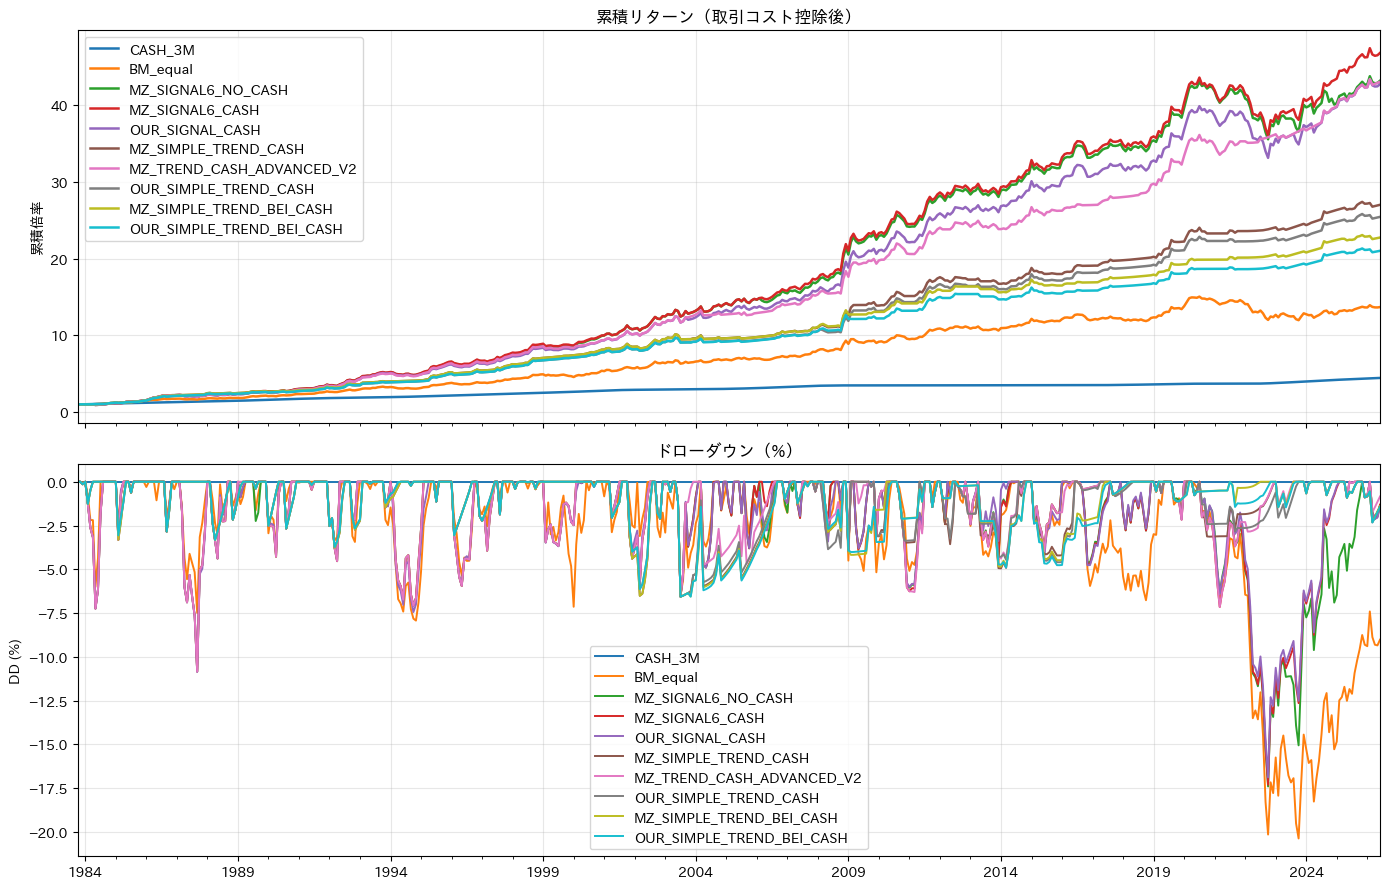

In [12]:
wealth = (1 + returns_net[compare_cols]).cumprod()
drawdown = wealth / wealth.cummax() - 1

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
wealth.plot(ax=axes[0], linewidth=1.8)
axes[0].set_title("累積リターン（取引コスト控除後）")
axes[0].set_ylabel("累積倍率")
axes[0].grid(True, alpha=0.3)

drawdown.mul(100).plot(ax=axes[1], linewidth=1.4)
axes[1].set_title("ドローダウン（%）")
axes[1].set_ylabel("DD (%)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 14. 2022年の挙動

この検証で最も重要なのは2022年である。

BM等加重債券は、金利レベル上昇により大きく下落した。ここで、`SIMPLE_TREND_CASH` がどれだけCashへ寄れたかを確認する。

特に見るべき点は、次の2つである。

1. 月次リターンがCashに近づいたか
2. Cash比率が2021年末から2022年にかけて十分に上がったか

2022年リターン（取引コスト控除後, 単純合計）


,2022 Return %
CASH_3M,1.86
BM_equal,-14.69
MZ_SIGNAL6_NO_CASH,-10.81
MZ_SIGNAL6_CASH,-10.69
OUR_SIGNAL_CASH,-10.74
MZ_SIMPLE_TREND_CASH,1.70
MZ_TREND_CASH_ADVANCED_V2,2.22
OUR_SIMPLE_TREND_CASH,1.70
MZ_SIMPLE_TREND_BEI_CASH,1.70
OUR_SIMPLE_TREND_BEI_CASH,1.70


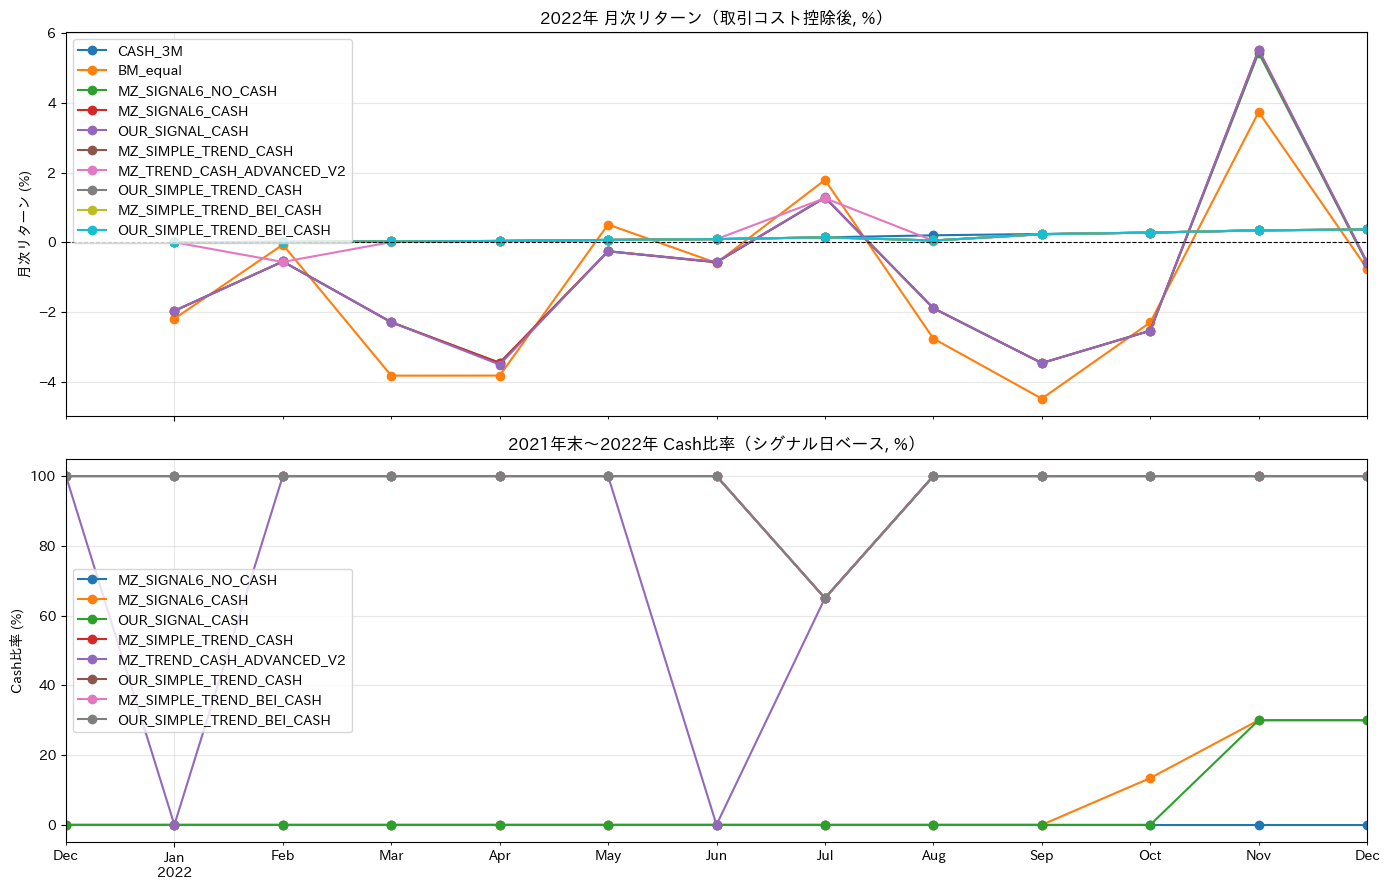

,MZ_SIGNAL6_NO_CASH,MZ_SIGNAL6_CASH,OUR_SIGNAL_CASH,MZ_SIMPLE_TREND_CASH,MZ_TREND_CASH_ADVANCED_V2,OUR_SIMPLE_TREND_CASH,MZ_SIMPLE_TREND_BEI_CASH,OUR_SIMPLE_TREND_BEI_CASH
2021-12-31,0.0,0.000,0.0,1.00,1.00,1.00,1.00,1.00
2022-01-31,0.0,0.000,0.0,1.00,0.00,1.00,1.00,1.00
2022-02-28,0.0,0.000,0.0,1.00,1.00,1.00,1.00,1.00
2022-03-31,0.0,0.000,0.0,1.00,1.00,1.00,1.00,1.00
2022-04-30,0.0,0.000,0.0,1.00,1.00,1.00,1.00,1.00
2022-05-31,0.0,0.000,0.0,1.00,1.00,1.00,1.00,1.00
2022-06-30,0.0,0.000,0.0,1.00,0.00,1.00,1.00,1.00
2022-07-31,0.0,0.000,0.0,0.65,0.65,0.65,0.65,0.65
2022-08-31,0.0,0.000,0.0,1.00,1.00,1.00,1.00,1.00
2022-09-30,0.0,0.000,0.0,1.00,1.00,1.00,1.00,1.00


In [13]:
print("2022年リターン（取引コスト控除後, 単純合計）")
display((returns_net.loc["2022", compare_cols].sum() * 100).round(2).to_frame("2022 Return %"))

cash_2022 = pd.DataFrame({
    name: weight_dfs[name].loc["2021-12-31":"2022-12-31", "Cash"]
    for name in strategy_config
})

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
returns_net.loc["2022", compare_cols].mul(100).plot(ax=axes[0], marker="o")
axes[0].set_title("2022年 月次リターン（取引コスト控除後, %）")
axes[0].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[0].set_ylabel("月次リターン (%)")
axes[0].grid(True, alpha=0.3)

cash_2022.mul(100).plot(ax=axes[1], marker="o")
axes[1].set_title("2021年末〜2022年 Cash比率（シグナル日ベース, %）")
axes[1].set_ylabel("Cash比率 (%)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

display(cash_2022.round(3))

## 15. トレンドペナルティの確認

`SIMPLE_TREND_CASH` と `MZ_TREND_CASH_ADVANCED_V2` はブラックボックスではない。各月のペナルティは、2年金利、3か月金利、10年金利、BEI、2s10スプレッドから直接決まる。

ここでは、名目金利トレンド、BEI込みトレンド、Advanced V2の防御圧力、逆イールドCashハードルがどの時期に大きくなったかを確認する。


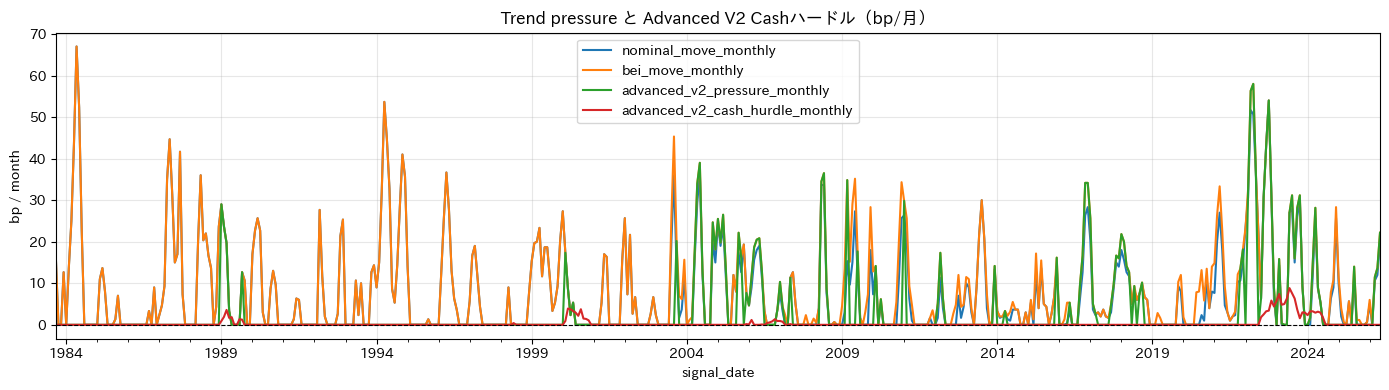

,signal_date,return_date,nominal_move_monthly,bei_move_monthly,advanced_v2_pressure_monthly,advanced_v2_cash_hurdle_monthly,advanced_v2_defense_flag,advanced_v2_policy_inflation_flag,advanced_v2_inversion_flag,signed_DGS3MO_move_monthly,signed_DGS2_move_monthly,signed_DGS10_move_monthly,signed_BEI_move_monthly,curve_2y10y_spread,DGS3MO_3m_change,DGS2_3m_change,DGS10_3m_change,T10YIE_3m_change
501,2025-06-30,2025-07-31,0.000033,0.000033,0.000000,0.0,False,False,False,0.000300,-0.000567,0.000033,-0.000300,-0.52,0.09,-0.17,0.01,-0.09
502,2025-07-31,2025-08-31,0.001133,0.001400,0.001400,0.0,True,True,False,0.000333,0.001133,0.000667,0.000533,-0.43,0.10,0.34,0.20,0.16
503,2025-08-31,2025-09-30,0.000000,0.000117,0.000000,0.0,False,False,False,-0.000433,-0.001000,-0.000600,0.000233,-0.64,-0.13,-0.30,-0.18,0.07
504,2025-09-30,2025-10-31,0.000000,0.000117,0.000000,0.0,False,False,False,-0.001300,-0.000400,-0.000267,0.000233,-0.56,-0.39,-0.12,-0.08,0.07
505,2025-10-31,2025-11-30,0.000000,0.000000,0.000000,0.0,False,False,False,-0.001733,-0.001133,-0.000867,-0.000300,-0.51,-0.52,-0.34,-0.26,-0.09
506,2025-11-30,2025-12-31,0.000000,0.000000,0.000000,0.0,False,False,False,-0.001167,-0.000400,-0.000700,-0.000600,-0.55,-0.35,-0.12,-0.21,-0.18
507,2025-12-31,2026-01-31,0.000067,0.000067,0.000000,0.0,False,False,False,-0.001167,-0.000433,0.000067,-0.000367,-0.71,-0.35,-0.13,0.02,-0.11
508,2026-01-31,2026-02-28,0.000500,0.000600,0.000000,0.0,False,False,False,-0.000733,-0.000267,0.000500,0.000200,-0.74,-0.22,-0.08,0.15,0.06
509,2026-02-28,2026-03-31,0.000000,0.000033,0.000000,0.0,False,False,False,-0.000700,-0.000300,-0.000167,0.000067,-0.59,-0.21,-0.09,-0.05,0.02
510,2026-03-31,2026-04-30,0.001067,0.001150,0.001150,0.0,True,True,False,0.000100,0.001067,0.000400,0.000167,-0.51,0.03,0.32,0.12,0.05


In [14]:
trend_plot = trend_df.set_index("signal_date")[[
    "nominal_move_monthly",
    "bei_move_monthly",
    "advanced_v2_pressure_monthly",
    "advanced_v2_cash_hurdle_monthly",
]] * 10000

fig, ax = plt.subplots(figsize=(14, 4))
trend_plot.plot(ax=ax, linewidth=1.5)
ax.set_title("Trend pressure と Advanced V2 Cashハードル（bp/月）")
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_ylabel("bp / month")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

display(trend_df.tail(12))


## 16. 制約チェックと結果保存

最後に、保存前に機械的なチェックを行う。

確認するのは、実装ミスとして起きやすい点である。

- リターンにNaNや無限大がない
- ウェイト合計が1である
- Cashが0%から100%に収まる。`NO_CASH` 版は全月0%である
- 債券セクター上限35%を満たす
- ポートフォリオDuration上限8年を満たす
- `returns_gross - returns_net = turnover × 2bp` が成立する

その後、Excelに保存する。

In [15]:
check_rows = []

check_rows.append(("returns_netにNaNなし", int(returns_net.isna().sum().sum()) == 0))
check_rows.append(("returns_grossにNaNなし", int(returns_gross.isna().sum().sum()) == 0))
check_rows.append(("returns_netが有限", np.isfinite(returns_net.values).all()))
check_rows.append(("returns_grossが有限", np.isfinite(returns_gross.values).all()))

for name, wdf in weight_dfs.items():
    check_rows.append((f"{name}: ウェイト合計=1", np.allclose(wdf.sum(axis=1).values, 1.0, atol=1e-10)))
    check_rows.append((f"{name}: Cash範囲", ((wdf["Cash"] >= -1e-10) & (wdf["Cash"] <= 1 + 1e-10)).all()))
    if not strategy_config[name]["cash"]:
        check_rows.append((f"{name}: Cashなし", np.allclose(wdf["Cash"].values, 0.0, atol=1e-12)))
    check_rows.append((f"{name}: 債券上限35%", (wdf[SECTOR_NAMES].max().max() <= MAX_WEIGHT + 1e-10)))

    duration_values = []
    for dt, row in wdf.iterrows():
        row_sector = yields.loc[dt].values.astype(float)
        durations = np.array([modified_duration(row_sector[k] / 100, maturity) for k, maturity in enumerate(MATURITIES)])
        duration_values.append(row.values @ np.r_[durations, CASH_DURATION])
    check_rows.append((f"{name}: Duration上限", max(duration_values) <= MAX_PORTFOLIO_DURATION + 1e-10))

    cost_diff = returns_gross[name] - returns_net[name]
    expected_cost = turnover_df[name] * TRANSACTION_COST_BPS / 10000
    check_rows.append((f"{name}: 取引コスト一致", np.allclose(cost_diff.values, expected_cost.values, atol=1e-12)))

check_df = pd.DataFrame(check_rows, columns=["check", "ok"])
display(check_df)

if not check_df["ok"].all():
    raise RuntimeError("制約チェックに失敗した項目があります")

with pd.ExcelWriter(RESULT_PATH) as writer:
    returns_gross.to_excel(writer, sheet_name="returns_gross")
    returns_net.to_excel(writer, sheet_name="returns_net")
    summary_gross.to_excel(writer, sheet_name="summary_gross")
    summary_net.to_excel(writer, sheet_name="summary_net")
    turnover_df.to_excel(writer, sheet_name="turnover")
    trend_df.to_excel(writer, sheet_name="trend_components", index=False)
    check_df.to_excel(writer, sheet_name="checks", index=False)
    input_metadata.to_excel(writer, sheet_name="input_metadata", index=False)
    input_coverage.to_excel(writer, sheet_name="input_coverage", index=False)
    input_monthly_missing_check.to_excel(writer, sheet_name="input_missing_check")
    weight_sheet_names = {
        "MZ_TREND_CASH_ADVANCED_V2": "weights_MZ_ADVANCED_V2",
        "MZ_SIMPLE_TREND_BEI_CASH": "weights_MZ_SIMPLE_TREND_BEI",
        "OUR_SIMPLE_TREND_BEI_CASH": "weights_OUR_SIMPLE_TREND_BEI",
    }
    for name, wdf in weight_dfs.items():
        sheet_name = weight_sheet_names.get(name, f"weights_{name}"[:31])
        wdf.to_excel(writer, sheet_name=sheet_name)

print(f"保存完了: {RESULT_PATH}")


,check,ok
0,returns_netにNaNなし,True
1,returns_grossにNaNなし,True
2,returns_netが有限,True
3,returns_grossが有限,True
4,MZ_SIGNAL6_NO_CASH: ウェイト合計=1,True
5,MZ_SIGNAL6_NO_CASH: Cash範囲,True
6,MZ_SIGNAL6_NO_CASH: Cashなし,True
7,MZ_SIGNAL6_NO_CASH: 債券上限35%,True
8,MZ_SIGNAL6_NO_CASH: Duration上限,True
9,MZ_SIGNAL6_NO_CASH: 取引コスト一致,True


保存完了: ../data/backtest_simple_trend_cash_comparison.xlsx


## 17. 読み取り

このノートブックは、現行Earlyゲートの置き換え候補を作るための検証である。

読み取りの軸は5つである。

1. **MZ no cash vs MZ cash**  
   宮崎型シグナルを債券13セクターだけで使う場合と、Cash退避を許す場合で、リターン、DD、2022年損失がどう変わるか。

2. **MZ vs OUR**  
   Miyazaki型の半年シグナルを月次化したものと、OURの月次残差平均回帰のどちらが、Cash込み最適化で有利か。

3. **SIMPLE_TREND_CASHの効果**  
   債券シグナルとCashを単純比較するだけでは、2022年のようなレベル損失を避けにくい。金利上昇トレンドをデュレーション損失として控除することで、Cashへの退避がどれだけ改善するか。

4. **Advanced V2の効果**  
   政策・インフレ型の引き締め、または2s10逆イールドの局面だけ防御することで、2011-2017年の取り逃がしと2022年防御をどこまで両立できるか。

5. **BEI Momentumの追加価値**  
   BEIを閾値ゲートとして使わず、上昇ペースを小さく足すだけで、インフレ期待上昇局面への防御が改善するか。

もしAdvanced V2が、`MZ_SIMPLE_TREND_CASH` に近い2022年防御を保ちながら2011-2017年のリターンを改善するなら、最終戦略候補として優先度が高い。逆に改善が限定的なら、説明可能性を重視して `MZ_SIMPLE_TREND_CASH` を主候補に残す。


## 18. Advanced V2 防御シグナルの診断

最後に、`MZ_TREND_CASH_ADVANCED_V2` の防御フラグと防御圧力が、実際に翌月の金利上昇リスクと関係しているかを確認する。

ここで検証するのは、戦略リターンそのものではなく、V2が防御モードに入る月が、翌月の金利上昇リスクをどの程度捉えているかである。

- 説明変数: 月末 $t$ の `advanced_v2_pressure_monthly` と `advanced_v2_cash_hurdle_monthly`
- 防御判定: `advanced_v2_defense_flag`
- 目的変数: 翌月の2年金利変化、10年金利変化、2年・10年のうち大きい方の金利変化。表示はbp換算
- 判定: 防御モードの月に翌月金利が上がりやすいか、また防御スコアが高い分位ほど翌月金利上昇が大きいか

この検証も、翌月の金利変化は診断用の目的変数としてだけ使い、ウェイト決定には使わない。


Advanced V2 defense score と翌月金利変化の相関


,corr_with_v2_defense_score
next_DGS2_1m_change_bp,0.103
next_DGS10_1m_change_bp,0.077
next_max_2y10y_1m_change_bp,0.104


防御flagの単純診断（%表示。ただし月数は実数）


,value
月数,513.00
防御モード月比率,22.22
政策・インフレflag月比率,14.04
2s10逆イールドflag月比率,10.72
"翌月max(2Y,10Y)上昇率",54.58
防御flagと翌月上昇の方向一致率,50.10
防御モード時の翌月上昇率,60.53
非防御モード時の翌月上昇率,52.88


Advanced V2 defense score 分位別の翌月金利変化（bp、上昇率は%）


,months,avg_score_bp,avg_pressure_bp,avg_cash_hurdle_bp,next_DGS2_bp,next_DGS10_bp,next_max_2y10y_bp,next_max_up_rate
v2_score_quintile,,,,,,,,
Q1 lowest,103,0.00,0.00,0.00,-4.01,-3.15,3.13,45.63
Q2,102,0.00,0.00,0.00,-0.13,-0.59,4.80,56.86
Q3,103,0.00,0.00,0.00,-3.93,-1.91,4.98,51.46
Q4,102,0.12,0.00,0.12,-2.53,-2.98,2.25,54.90
Q5 highest,103,18.12,16.79,1.33,4.37,1.80,9.40,64.08


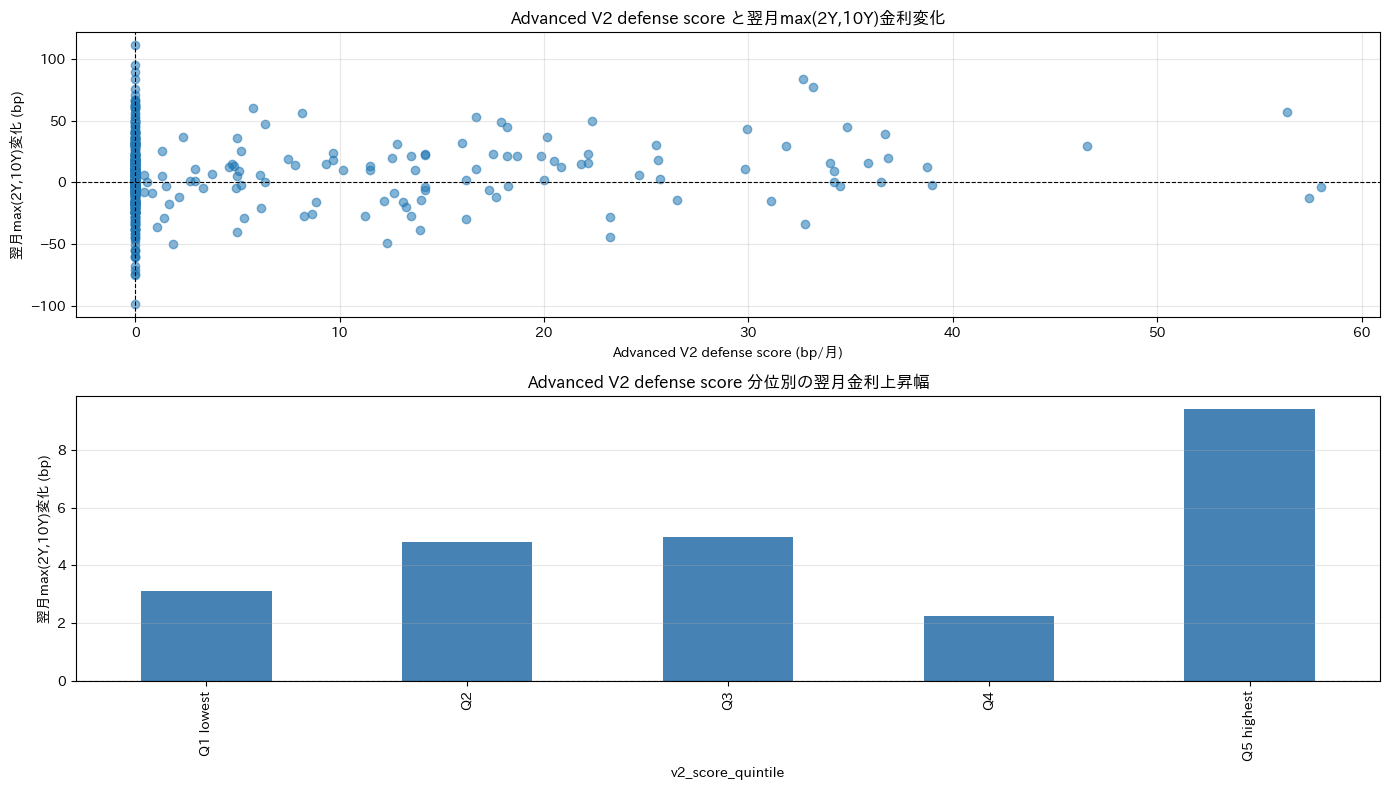

In [16]:
advanced_signal_check = trend_df.copy()
advanced_signal_check["signal_date"] = pd.to_datetime(advanced_signal_check["signal_date"])
advanced_signal_check["return_date"] = pd.to_datetime(advanced_signal_check["return_date"])

for col in ["DGS2", "DGS10"]:
    advanced_signal_check[f"next_{col}_1m_change_bp"] = [
        (macro.loc[ret_dt, col] - macro.loc[sig_dt, col]) * 100
        for sig_dt, ret_dt in zip(advanced_signal_check["signal_date"], advanced_signal_check["return_date"])
    ]

advanced_signal_check["next_max_2y10y_1m_change_bp"] = advanced_signal_check[
    ["next_DGS2_1m_change_bp", "next_DGS10_1m_change_bp"]
].max(axis=1)
advanced_signal_check["advanced_v2_pressure_bp"] = advanced_signal_check["advanced_v2_pressure_monthly"] * 10000
advanced_signal_check["advanced_v2_cash_hurdle_bp"] = advanced_signal_check["advanced_v2_cash_hurdle_monthly"] * 10000
advanced_signal_check["advanced_v2_defense_score_bp"] = (
    advanced_signal_check["advanced_v2_pressure_bp"] + advanced_signal_check["advanced_v2_cash_hurdle_bp"]
)
advanced_signal_check["defense_active"] = advanced_signal_check["advanced_v2_defense_flag"].astype(bool)
advanced_signal_check["actual_up_next_max"] = advanced_signal_check["next_max_2y10y_1m_change_bp"] > 0

corr_cols = [
    "next_DGS2_1m_change_bp",
    "next_DGS10_1m_change_bp",
    "next_max_2y10y_1m_change_bp",
]
predictive_corr = advanced_signal_check[["advanced_v2_defense_score_bp"] + corr_cols].corr().loc[
    "advanced_v2_defense_score_bp", corr_cols
].to_frame("corr_with_v2_defense_score")

hit_rate_table = pd.DataFrame({
    "月数": [len(advanced_signal_check)],
    "防御モード月比率": [advanced_signal_check["defense_active"].mean()],
    "政策・インフレflag月比率": [advanced_signal_check["advanced_v2_policy_inflation_flag"].mean()],
    "2s10逆イールドflag月比率": [advanced_signal_check["advanced_v2_inversion_flag"].mean()],
    "翌月max(2Y,10Y)上昇率": [advanced_signal_check["actual_up_next_max"].mean()],
    "防御flagと翌月上昇の方向一致率": [(advanced_signal_check["defense_active"] == advanced_signal_check["actual_up_next_max"]).mean()],
    "防御モード時の翌月上昇率": [advanced_signal_check.loc[advanced_signal_check["defense_active"], "actual_up_next_max"].mean()],
    "非防御モード時の翌月上昇率": [advanced_signal_check.loc[~advanced_signal_check["defense_active"], "actual_up_next_max"].mean()],
}).T.rename(columns={0: "value"})

hit_rate_display = hit_rate_table.copy()
percent_rows = hit_rate_display.index != "月数"
hit_rate_display.loc[percent_rows, "value"] = hit_rate_display.loc[percent_rows, "value"] * 100

advanced_signal_check["v2_score_quintile"] = pd.qcut(
    advanced_signal_check["advanced_v2_defense_score_bp"].rank(method="first"),
    5,
    labels=["Q1 lowest", "Q2", "Q3", "Q4", "Q5 highest"],
)
quintile_table = advanced_signal_check.groupby("v2_score_quintile", observed=True).agg(
    months=("advanced_v2_defense_score_bp", "size"),
    avg_score_bp=("advanced_v2_defense_score_bp", "mean"),
    avg_pressure_bp=("advanced_v2_pressure_bp", "mean"),
    avg_cash_hurdle_bp=("advanced_v2_cash_hurdle_bp", "mean"),
    next_DGS2_bp=("next_DGS2_1m_change_bp", "mean"),
    next_DGS10_bp=("next_DGS10_1m_change_bp", "mean"),
    next_max_2y10y_bp=("next_max_2y10y_1m_change_bp", "mean"),
    next_max_up_rate=("actual_up_next_max", "mean"),
)
quintile_display = quintile_table.copy()
quintile_display["next_max_up_rate"] = quintile_display["next_max_up_rate"] * 100

print("Advanced V2 defense score と翌月金利変化の相関")
display(predictive_corr.round(3))
print("防御flagの単純診断（%表示。ただし月数は実数）")
display(hit_rate_display.round(2))
print("Advanced V2 defense score 分位別の翌月金利変化（bp、上昇率は%）")
display(quintile_display.round(2))

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)
axes[0].scatter(
    advanced_signal_check["advanced_v2_defense_score_bp"],
    advanced_signal_check["next_max_2y10y_1m_change_bp"],
    alpha=0.55,
)
axes[0].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[0].axvline(0, color="black", linewidth=0.8, linestyle="--")
axes[0].set_title("Advanced V2 defense score と翌月max(2Y,10Y)金利変化")
axes[0].set_xlabel("Advanced V2 defense score (bp/月)")
axes[0].set_ylabel("翌月max(2Y,10Y)変化 (bp)")
axes[0].grid(True, alpha=0.3)

quintile_table["next_max_2y10y_bp"].plot(kind="bar", ax=axes[1], color="steelblue")
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_title("Advanced V2 defense score 分位別の翌月金利上昇幅")
axes[1].set_ylabel("翌月max(2Y,10Y)変化 (bp)")
axes[1].grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

advanced_predictive_summary = {
    "predictive_corr": predictive_corr,
    "hit_rate_table": hit_rate_table,
    "quintile_table": quintile_table,
}
